In [1]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-10/option_chain_nifty_2026-12-29_full_history.csv"



In [2]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [3]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([], dtype=int32)

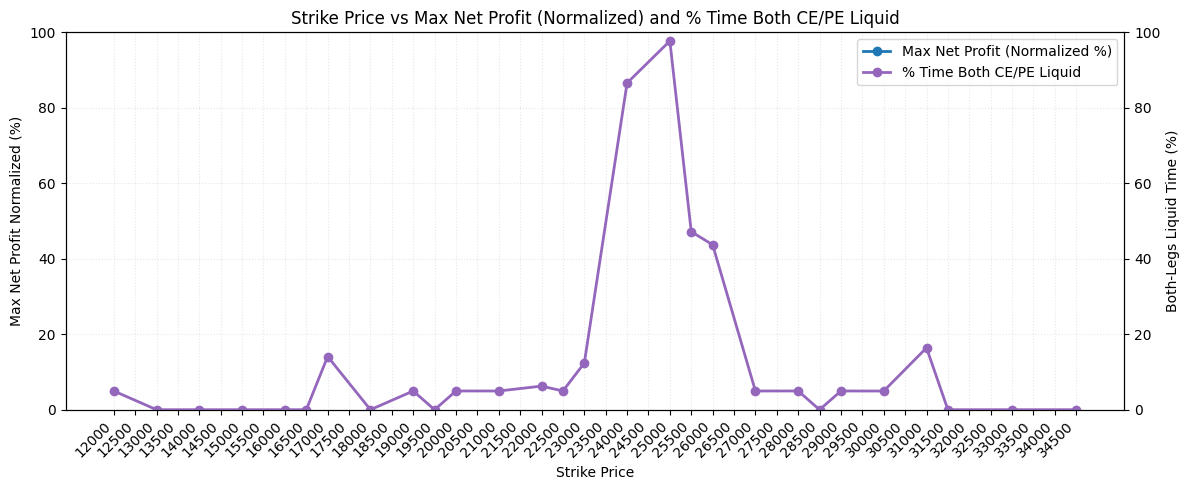

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,12000,NaN,NaN,4.961832
1,13000,NaN,NaN,0.000000
2,14000,NaN,NaN,0.000000
3,15000,-503.258722,-37.669365,0.000000
4,16000,-533.457558,-39.929774,0.000000


In [4]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

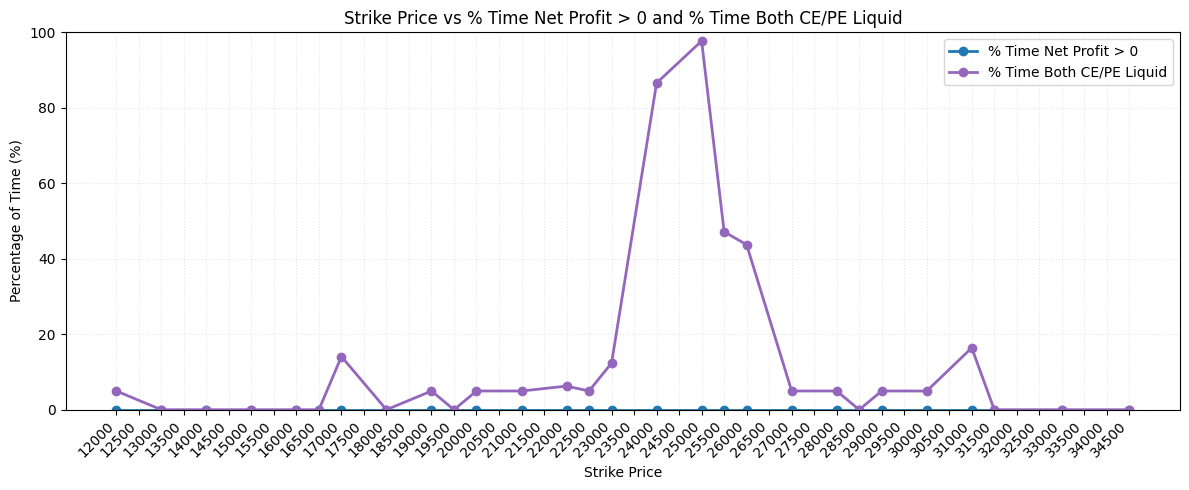

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,12000,0.0,4.961832
1,13000,0.0,0.000000
2,14000,0.0,0.000000
3,15000,0.0,0.000000
4,16000,0.0,0.000000


In [5]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

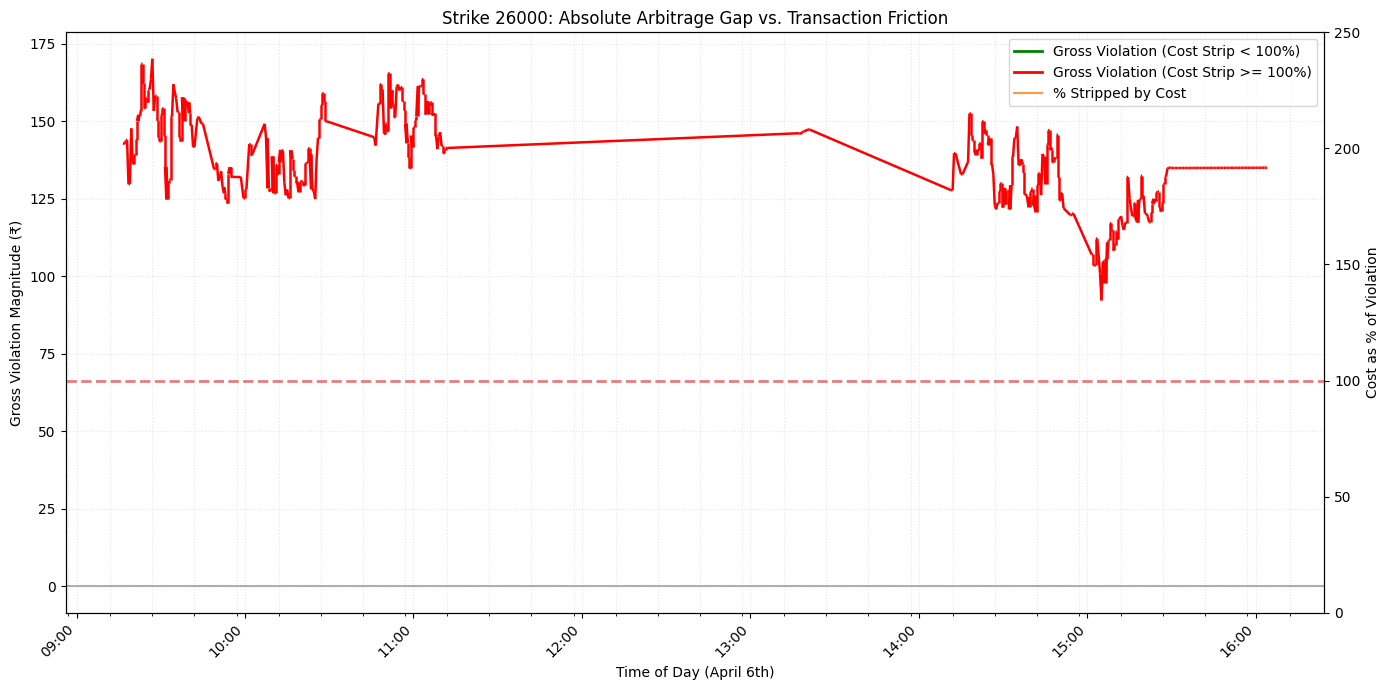

,fetch_time,abs_violation,cost,cost_stripped_pct
18,2026-04-10 09:16:30,142.828736,1217.786556,852.620129
46,2026-04-10 09:17:00,142.830158,1217.785037,852.610581
130,2026-04-10 09:17:00,143.330158,1217.772880,849.627811
158,2026-04-10 09:17:30,143.331579,1217.771361,849.618326
242,2026-04-10 09:17:30,143.981579,1217.719259,845.746566
...,...,...,...,...
83626,2026-04-10 16:02:00,135.031451,1217.602142,901.717437
83710,2026-04-10 16:02:30,135.032873,1217.600622,901.706820
83766,2026-04-10 16:03:00,135.034294,1217.599101,901.696202
83878,2026-04-10 16:03:30,135.035715,1217.597581,901.685585


In [6]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df[df['both_legs_liquid'] == True], strike=26000)

In [20]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

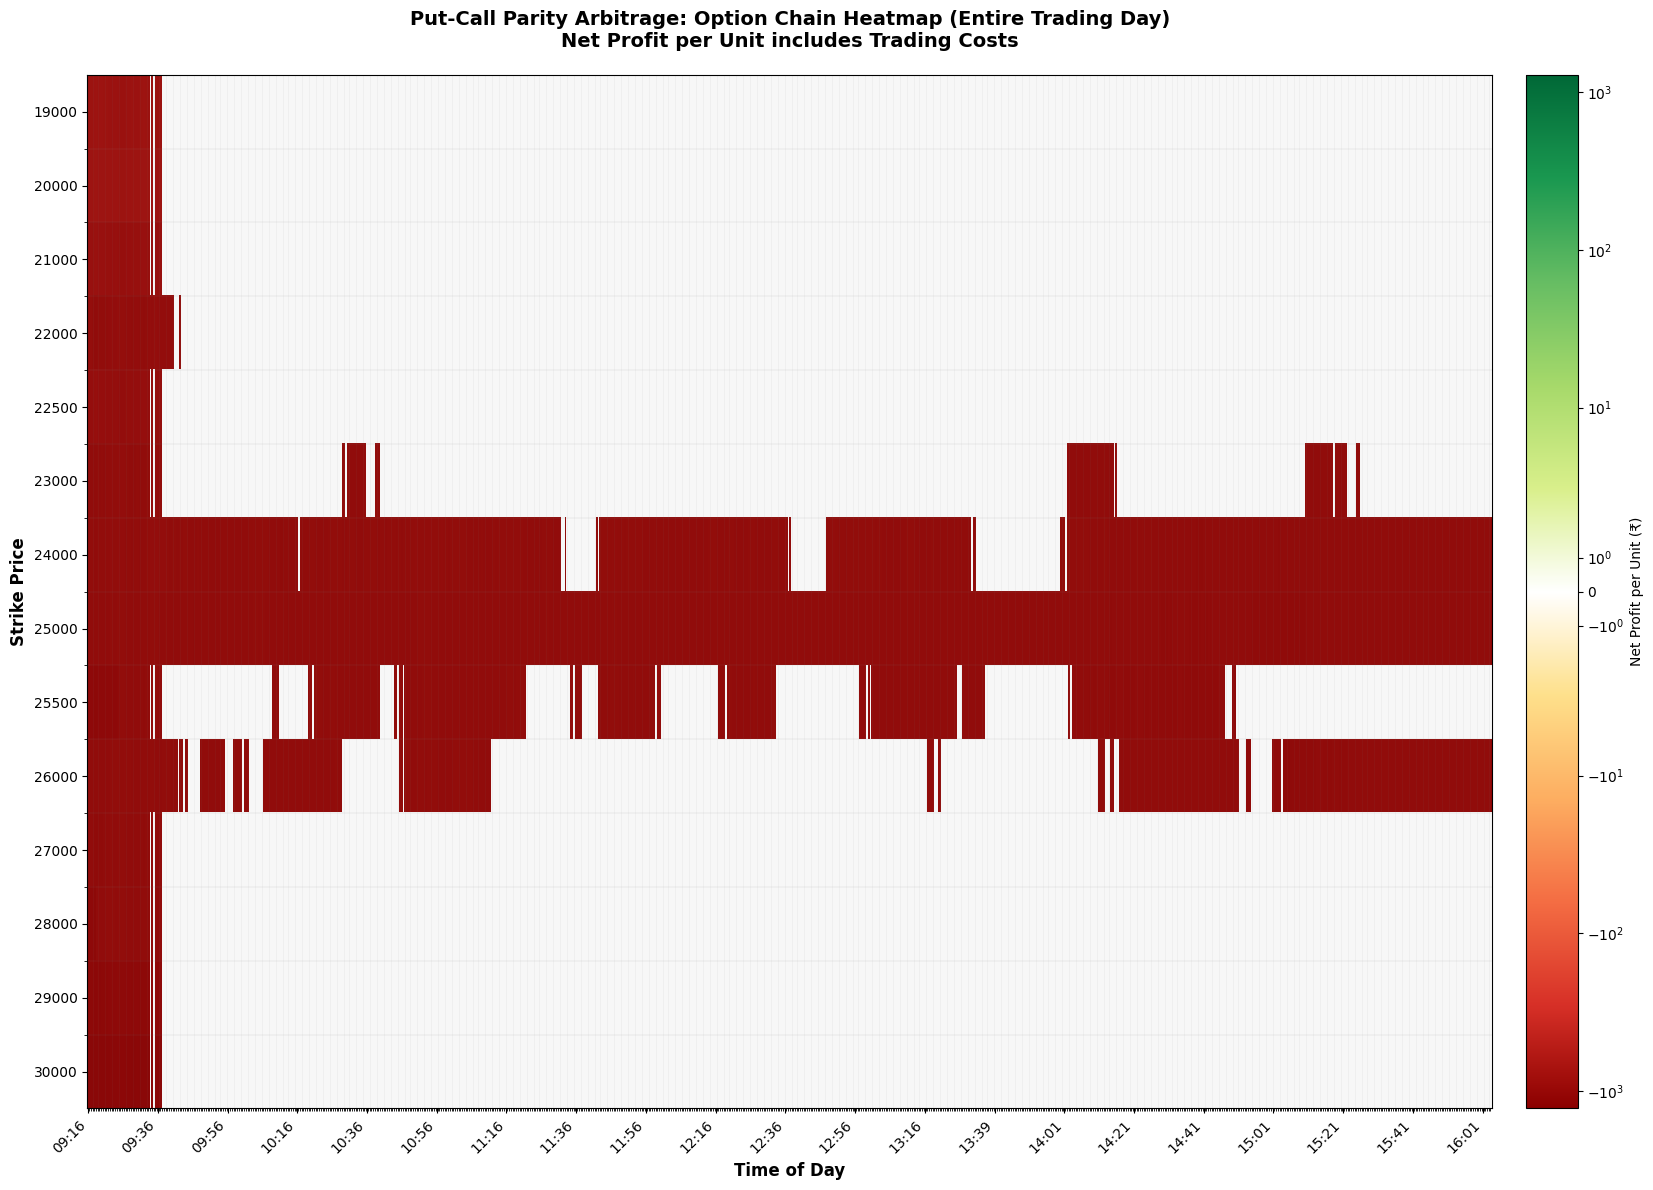

In [8]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the time
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.001,  # Smaller neutral band for faster color transition
)

In [9]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'pe_growwContractId', 'pe_displayName', 'pe_longDisplayName',
       'pe_token', 'pe_marketLot', 'pe_liveData_close', 'pe_liveData_ltp',
       'pe_liveData_dayChange', 'pe_liveData_dayChangePerc', 'pe_liveData_oi',
       'pe_liveData_prevOI', 'pe_greeks_delta', 'pe_greeks_gamma',
       'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho', 'pe_greeks_iv',
       'pe_greeks_pop', 'pe_markers', 'ce_growwContractId', 'ce_displayName',
       'ce_longDisplayName', 'ce_token', 'ce_marketLot', 'ce_liveData_close',
       'ce_liveData_ltp', 'ce_liveData_dayChange', 'ce_liveData_dayChangePerc',
       'ce_liveData_oi', 'ce_liveData_prevOI', 'ce_greeks_delta',
       'ce_greeks_gamma', 'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho',
       'ce_greeks_iv', 'ce_greeks_pop', 'ce_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation

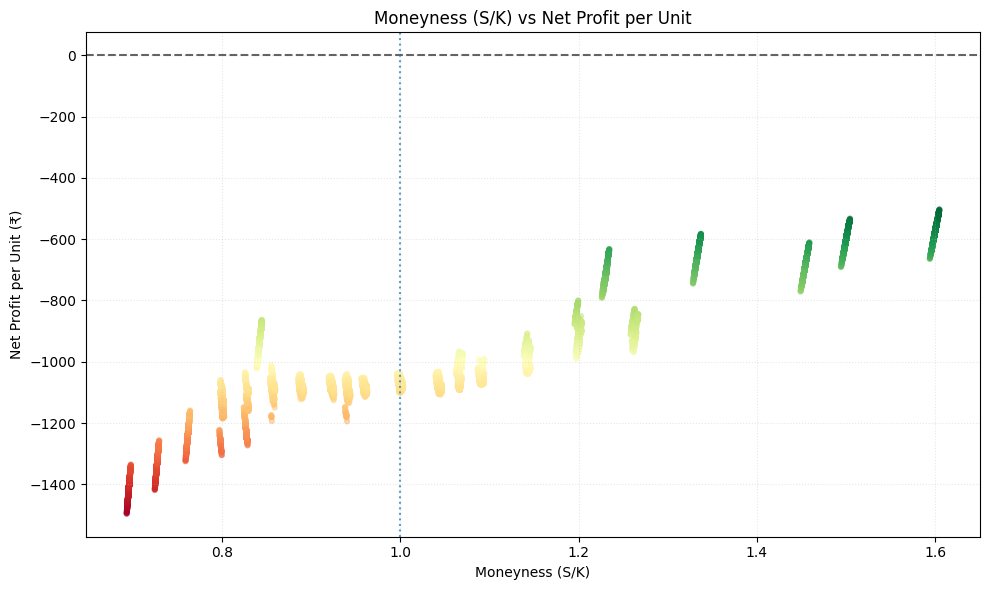

,moneyness,net_profit_per_unit
0,1.996046,NaN
1,1.842504,NaN
2,1.710896,NaN
3,1.596837,-616.074119
4,1.497034,-645.568436


In [10]:
# SCATTER: Moneyness (S/K) vs Net Profit per Unit
moneyness_df = utils.plot_moneyness_vs_net_profit(
    df,
    min_liquidity=0,
)
moneyness_df.head()

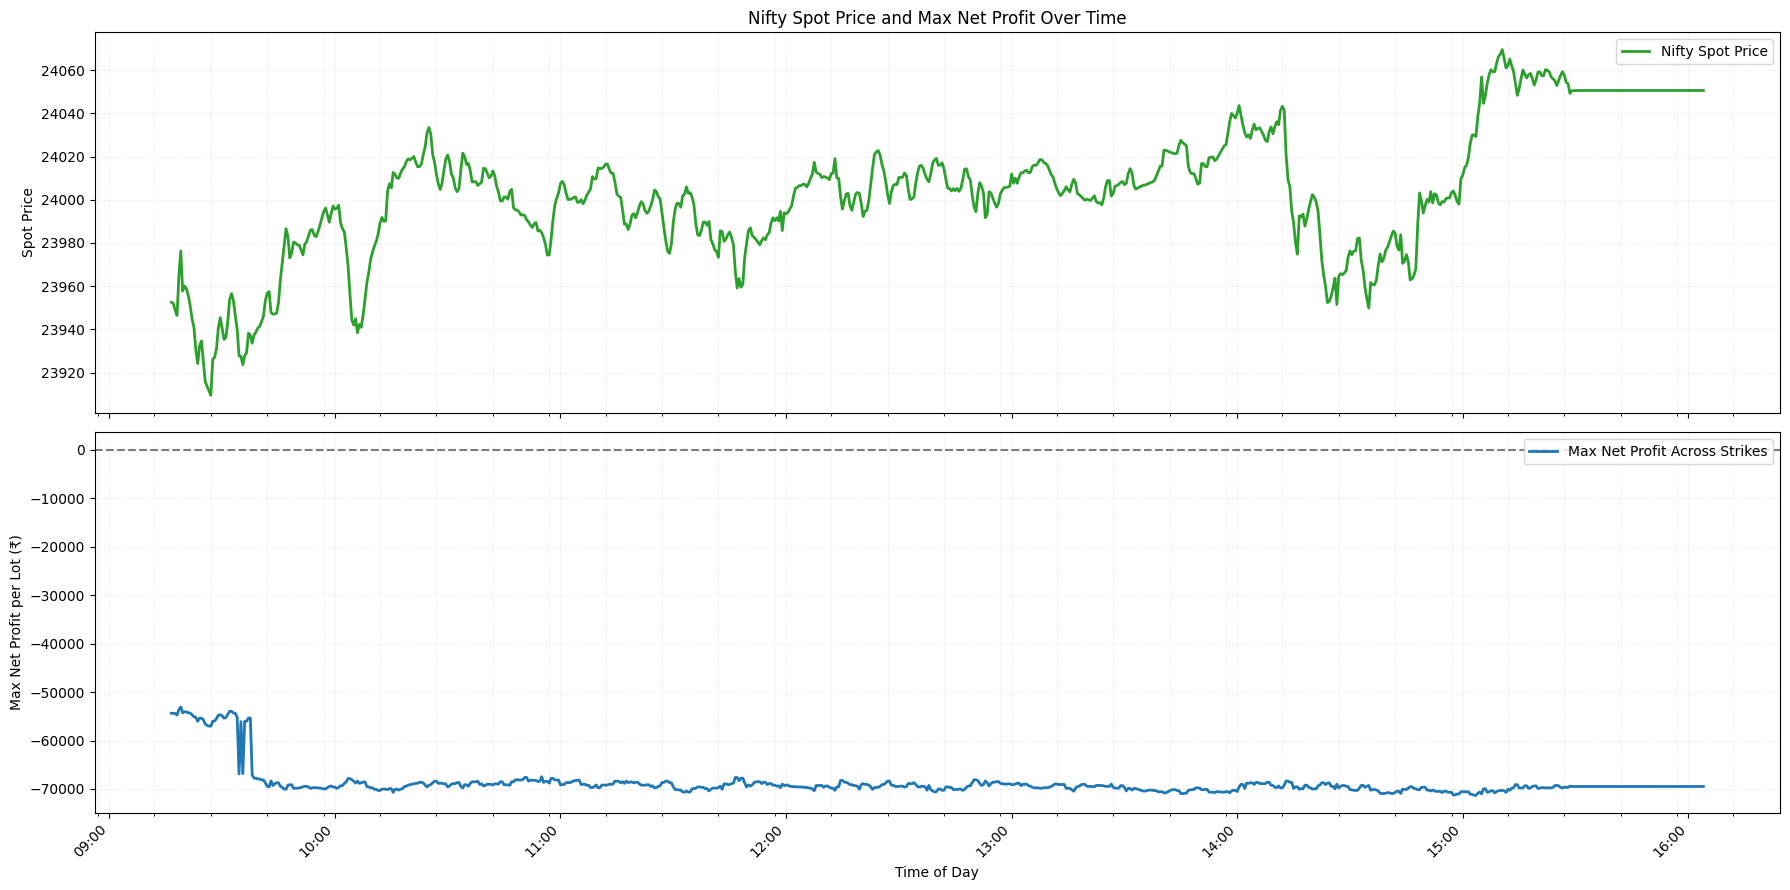

,fetch_time,spot_price,max_profit
0,2026-04-10 09:16:30,23952.550,-54371.436774
1,2026-04-10 09:17:00,23952.025,-54371.427074
2,2026-04-10 09:17:30,23948.975,-54438.958416
3,2026-04-10 09:18:00,23946.450,-54734.605465
4,2026-04-10 09:18:30,23964.900,-53612.655377


In [11]:
# TWO-PANEL VIEW: Spot Price (Top) and Max Net Profit Across Strikes (Bottom)
spot_profit_df = utils.plot_spot_and_max_profit_over_time(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    trading_cost=True,
    per_lot=True,
    figsize=(18, 9),
)
spot_profit_df.head()

No rows available for the selected filter. Returning zero cost breakdown.


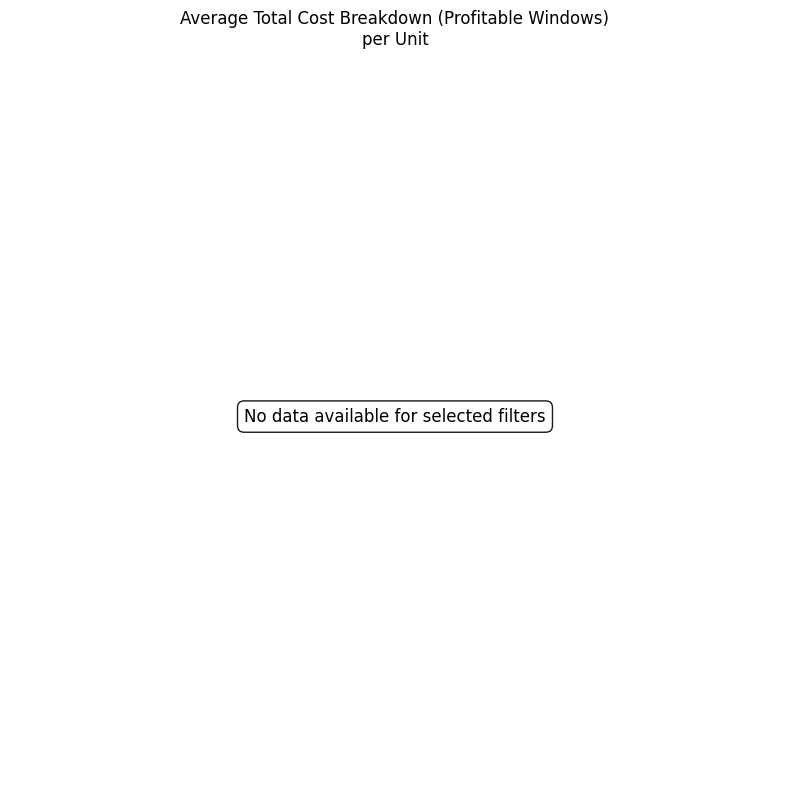

,avg_cost_per_unit
Brokerage,0.0
STT,0.0
GST,0.0
Funding/Margin,0.0
Total,0.0


In [21]:
# COST BREAKDOWN PIE: Average total_cost in profitable windows
cost_breakdown = utils.plot_avg_cost_breakdown_pie(
    df[df['both_legs_liquid'] == True],
    profitable_only=True,
    min_liquidity=0,
    per_lot=False,
)
cost_breakdown

In [ ]:
# OPPORTUNITY SPLIT (Pie): Conversion vs Reversal for profitable rows
opportunity_split = utils.plot_opportunity_split_pie(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    require_liquid=False,
)
opportunity_split

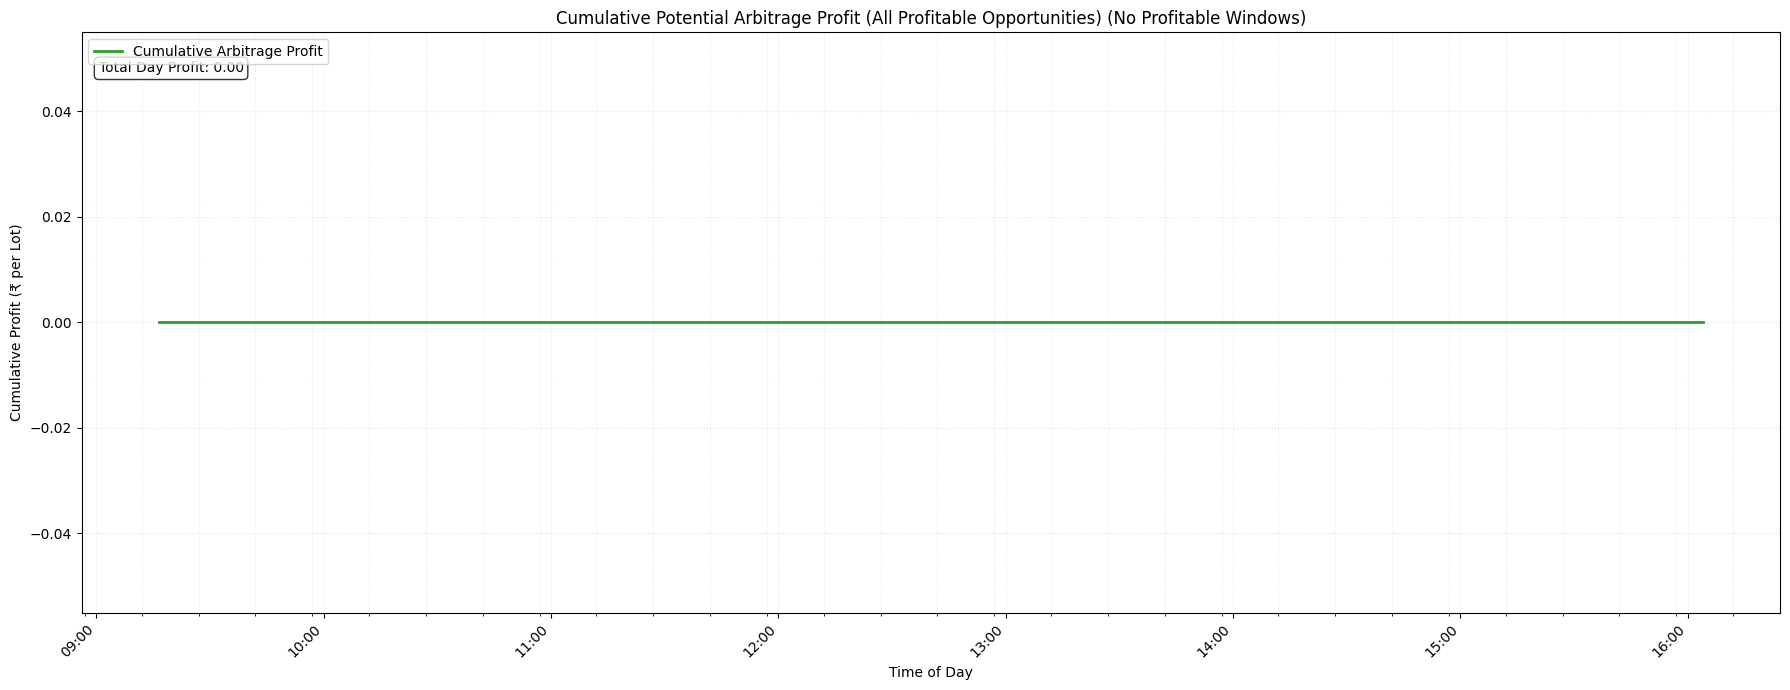

,fetch_time,interval_profit,opportunities_count,cumulative_profit
83614,2026-04-10 16:02:00,0.0,0,0.0
83698,2026-04-10 16:02:30,0.0,0,0.0
83754,2026-04-10 16:03:00,0.0,0,0.0
83866,2026-04-10 16:03:30,0.0,0,0.0
83950,2026-04-10 16:04:00,0.0,0,0.0


In [17]:
# CUMSUM ARBITRAGE PROFIT: 1 lot at every profitable opportunity across strikes
cumsum_profit_df = utils.plot_cumsum_arbitrage_profit_all_opportunities(
     df,
    require_liquid=True,
    min_liquidity=0,
    per_lot=True,
    figsize=(18, 7),
)
cumsum_profit_df.tail()